In [1]:

import os
# Make sure you are in scMEDAL_for_scRNAseq dir
os.chdir("/archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/dev2/scMEDAL_for_scRNAseq")

#from models.models import train_model_on_named_experiment

In [ ]:

os.getcwd()

## Training Models:

#### Implemented Models:
| Model Class | Model Description | 
|------------|--------------------|  
| `AE` | Autoencoder | 
| `AEC`| Autoencoder Classifier |
| `scMEDAL-FE` | Domain Adversarial Autoencoder |
| `scMEDAL-FEC`| Domain Adversarial Autoencoder Classifier |
| `scMEDAL-RE`| Domain Enhancing Autoencoder Classifier | 

#### Named Experiments:
| Valid Named Experiment | Dataset |  n_clusters | n_pred |
|------------------------|---------|-------------|--------|
| `AML`| Acute Myeloid Leukemia | 19 | 21 |
| `ASD`| Autism Spectrum Disorder | 31 | 17 | 
| `HH` | Healthy Heart | 147 | 13 | 

**Note:** If training on other datasets, the configs will need to be passed in as dictionaries to `model_kwargs` and `train_kwargs`.

`quick` is a boolean flag that can be passed to `train_kwargs` which shortens training to only 1 fold for 3 epochs.

Run models on all 3 datasets with

$python\ run\_scMEDAL\_alldatasets.py$

## Analyzing Models:

When you run a model, it generates the following output directories:
   - /outputs/figures
   - /outputs/latent_space
   - /outputs/saved_models
 
 Inside each of these directories, there is a subdirectory named after the model and its run identifier.
 
 For example: $AML/latent\_space/scmedalfe/run\_crossval\_<run\_name>$

 To analyze your results, copy the corresponding $<run\_name>$ below.

In [2]:

# When you run your model, it outputs the figures, latent_space and saved_models directories, whitin those directories you will find a subdir with the name of the model trained, example: AML/latent_space/scmedalfe/run_crossval_<run_name>
#Please copy the <run_name below> to analyze the results
# Update output paths of the models that you just run


from utils.defaults import AML_OUTPUTS_DIR,AML_EXPERIMENT_NAME
print(f"Loading outputs from {AML_OUTPUTS_DIR}. Please verify that your models output folder is located here before proceeding with the analysis.")
import os
model_folder_dict = {
    "ae":"run_crossval_n_latent_dims-50_layer_units-512-132_use_batch_norm-True_scaling-min_max_model_type-ae_batch_size-512_epochs-500_patience-30_compute_latents_callback-False_sample_size-10000_n_components-50_get_cf_batch-False_2025-07-09_23-06",
    "aec":"run_crossval_n_latent_dims-50_layer_units-512-132_n_pred-21_use_batch_norm-True_scaling-min_max_model_type-aec_batch_size-512_epochs-500_patience-30_compute_latents_callback-False_sample_size-10000_get_cf_batch-False_2025-07-09_23-54",
    "scmedalfe":"run_crossval_loss_gen_weight-1_loss_recon_weight-250_loss_class_weight-1_n_latent_dims-50_layer_units-512-132_scaling-min_max_model_type-scmedalfe_batch_size-512_epochs-500_patience-30_sample_size-10000_2025-07-09_22-09",
    "scmedalfec":"run_crossval_loss_gen_weight-1_loss_recon_weight-2000_loss_class_weight-1_n_latent_dims-50_layer_units-512-132_scaling-min_max_model_type-scmedalfec_batch_size-512_epochs-500_patience-30_sample_size-10000_get_cf_batch-False_2025-07-10_00-17",
    "scmedalre":"run_crossval_loss_recon_weight-110_loss_latent_cluster_weight-0.1_n_latent_dims-50_layer_units-512-132_scaling-min_max_batch_size-512_epochs-500_patience-30_sample_size-10000_2025-07-10_01-11",
    # To collect the comparable outputs (see below), you need to run the comparable models in /comparables. 

    # new runs
    "scVI":"run_crossval_n_latent_dims-50_n_layers-2_n_hidden-132_gene_likelihood-zinb_dispersion-gene_scaling-min_max_batch_size-512_epochs-500_patience-30_compute_latents_callback-False_sample_size-10000_model_type-ae_2025-07-16_19-16",
    "scANVI":"run_crossval_n_latent_dims-50_n_layers-2_n_hidden-132_gene_likelihood-zinb_dispersion-gene_scaling-min_max_batch_size-512_epochs-500_patience-30_compute_latents_callback-False_sample_size-10000_model_type-ae_2025-07-16_19-33",
    "scanorama":"run_crossval_n_latent_dims-50_scaling-min_max_sample_size-10000_model_type-ae_2025-07-16_19-42",
    "harmony":"run_crossval_n_latent_dims-50_scaling-min_max_sample_size-10000_model_type-ae_2025-07-16_19-17",
    "SAUCIE":"run_crossval_n_latent_dims-50_layers-512-132-50_lambda_b-0.0_lambda_c-0.0_lambda_d-0.0_learning_rate-0.0_scaling-min_max_batch_size-512_epochs-50_patience-30_sample_size-10000_model_type-ae_2025-07-16_22-57",

    }

model_paths = {k:os.path.join(AML_OUTPUTS_DIR, "latent_space", AML_EXPERIMENT_NAME,k, v) for k, v in model_folder_dict.items()}


OUTPUTS_DIR: /archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/dev2/scMEDAL_for_scRNAseq/outputs
Loading outputs from /archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/dev2/scMEDAL_for_scRNAseq/outputs/AML. Please verify that your models output folder is located here before proceeding with the analysis.


##### Step 1: Import the analysis class and initialize it

In [3]:

import analysis.analysis as aa

analysis_name = "AML_default_500_v1.3"
#analysis_name = "AML_default_500"



aml = aa.AMLAnalysis(model_folder_dict, analysis_name)

2025-07-31 19:58:54.485253: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-07-31 19:58:56.200447: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


##### Step 2: Compile clustering scores calculated after training the models

In [4]:


res= aml.clustering_scores(model_folder_dict)
# You can now inspect or export `clustering_results` as needed
# Note: if you only run 1 fold, you will see NAN in CI entries
res

[WARN] scVI: config.json not found: /archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/dev2/scMEDAL_for_scRNAseq/outputs/AML/saved_models/log_transformed_2916hvggenes/scVI/run_crossval_n_latent_dims-50_n_layers-2_n_hidden-132_gene_likelihood-zinb_dispersion-gene_scaling-min_max_batch_size-512_epochs-500_patience-30_compute_latents_callback-False_sample_size-10000_model_type-ae_2025-07-16_19-16/configs.json  using single-model format (AE will default to PCA format if present)
[WARN] scANVI: config.json not found: /archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/dev2/scMEDAL_for_scRNAseq/outputs/AML/saved_models/log_transformed_2916hvggenes/scANVI/run_crossval_n_latent_dims-50_n_layers-2_n_hidden-132_gene_likelihood-zinb_dispersion-gene_scaling-min_max_batch_size-512_epochs-500_patience-30_compute_latents_callback-False_sample_size-10000_model_type-ae_2025-07-16_19-33/configs.json  using single-model format (AE will default to PCA format if present)
[WARN] scanorama: config.jso

batch                                                          \
                1/db                         ch                   silhouette   
                mean CI_lower CI_upper     mean CI_lower CI_upper       mean   
dataset_type                                                                   
X_pca_test      0.20     0.20     0.20   109.69   108.51   110.86      -0.02   
ae_latent_test  0.19     0.19     0.20   117.36   112.13   122.59      -0.03   
SAUCIE          0.16     0.15     0.18   109.44    91.25   127.62      -0.12   
aec             0.15     0.14     0.16   143.11   110.81   175.42      -0.12   
harmony         0.14     0.05     0.22    71.37    22.16   120.58      -0.07   
scANVI          0.12     0.12     0.13    50.41    45.82    55.00      -0.19   
scVI            0.05     0.05     0.06    14.24    11.88    16.60      -0.24   
scanorama       0.16     0.10     0.21    85.09    53.43   116.76      -0.10   
scmedalfe       0.20     0.19     0.20   102.44    96.69   108.18      -0.02   
scmedalfec      0.18     0.17     0.18    98.06    95.41   100.71      -0.03   
scmedalre       1.50     1.29     1.71  7097.61  6162.38  8032.85       0.69   

                                 celltype                                      \
                                     1/db                         ch            
               CI_lower CI_upper     mean CI_lower CI_upper     mean CI_lower   
dataset_type                                                                    
X_pca_test        -0.03    -0.02     0.27     0.27     0.27   329.80   326.81   
ae_latent_test    -0.03    -0.02     0.27     0.26     0.27   400.15   355.55   
SAUCIE            -0.14    -0.10     0.30     0.29     0.32   638.71   493.41   
aec               -0.13    -0.12     0.36     0.31     0.40  1057.54   912.28   
harmony           -0.12    -0.01     0.21     0.13     0.29   298.48   263.40   
scANVI            -0.20    -0.17     0.61     0.58     0.64  1449.83  1397.16   
scVI              -0.24    -0.23     0.29     0.24     0.34   885.58   812.33   
scanorama         -0.21     0.00     0.25     0.22     0.28   393.25   253.51   
scmedalfe         -0.03    -0.02     0.27     0.26     0.27   315.42   297.35   
scmedalfec        -0.03    -0.03     0.26     0.25     0.26   311.35   301.43   
scmedalre          0.67     0.71     0.18     0.17     0.19   139.51   131.70   

                                                      
                        silhouette                    
               CI_upper       mean CI_lower CI_upper  
dataset_type                                          
X_pca_test       332.78       0.06     0.05     0.06  
ae_latent_test   444.75       0.06     0.05     0.06  
SAUCIE           784.01       0.04     0.02     0.05  
aec             1202.80       0.12     0.10     0.13  
harmony          333.57       0.04     0.01     0.06  
scANVI          1502.50       0.22     0.21     0.23  
scVI             958.83       0.03     0.02     0.04  
scanorama        532.99       0.03    -0.00     0.07  
scmedalfe        333.49       0.06     0.05     0.06  
scmedalfec       321.26       0.05     0.05     0.06  
scmedalre        147.32      -0.07    -0.08    -0.06

##### Step 3: Generate and save the UMAP plots

In [5]:

# This typically loads latent representations stored after training and creates UMAPs for each model
processors = aml.umap(model_folder_dict, types=["train"], splits=[1])
processors

Reading inputs and latent paths ..
umap saved to /archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/dev2/scMEDAL_for_scRNAseq/outputs/AML/compare_models/log_transformed_2916hvggenes/AML_default_500/umap_19batches_seed_5
Computing UMAP projections...


Processing input prefix: 0 train_1
Reading data from: /archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/scMEDAL_for_scRNAseq/Experiments/data/AML_data/log_transformed_2916hvggenes/splits/split_1/train


/archive/bioinformatics/DLLab/shared/CondaEnvironments/scMEDAL/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/archive/bioinformatics/DLLab/shared/CondaEnvironments/scMEDAL/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)



Scenario 2: Processing input subset batches (train_1)

Processing input sample
Computing UMAP on 23049 cells * 2916 features, using 'X_pca'
UMAP shape: (23049, 2)

Scenario 4: Processing latent subset batches (train_1)

Processing: ae_latent_train_1
Computing UMAP on 23049 cells * 50 features, using 'X'


/archive/bioinformatics/DLLab/shared/CondaEnvironments/scMEDAL/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


UMAP shape: (23049, 2)


...


Processing: scanorama_latent_train_1
Computing UMAP on 23049 cells * 50 features, using 'X'
UMAP shape: (23049, 2)


/archive/bioinformatics/DLLab/shared/CondaEnvironments/scMEDAL/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)



Processing: harmony_latent_train_1
Computing UMAP on 23049 cells * 50 features, using 'X'
UMAP shape: (23049, 2)


/archive/bioinformatics/DLLab/shared/CondaEnvironments/scMEDAL/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)



Processing: SAUCIE_latent_train_1
Computing UMAP on 23049 cells * 50 features, using 'X'
UMAP shape: (23049, 2)



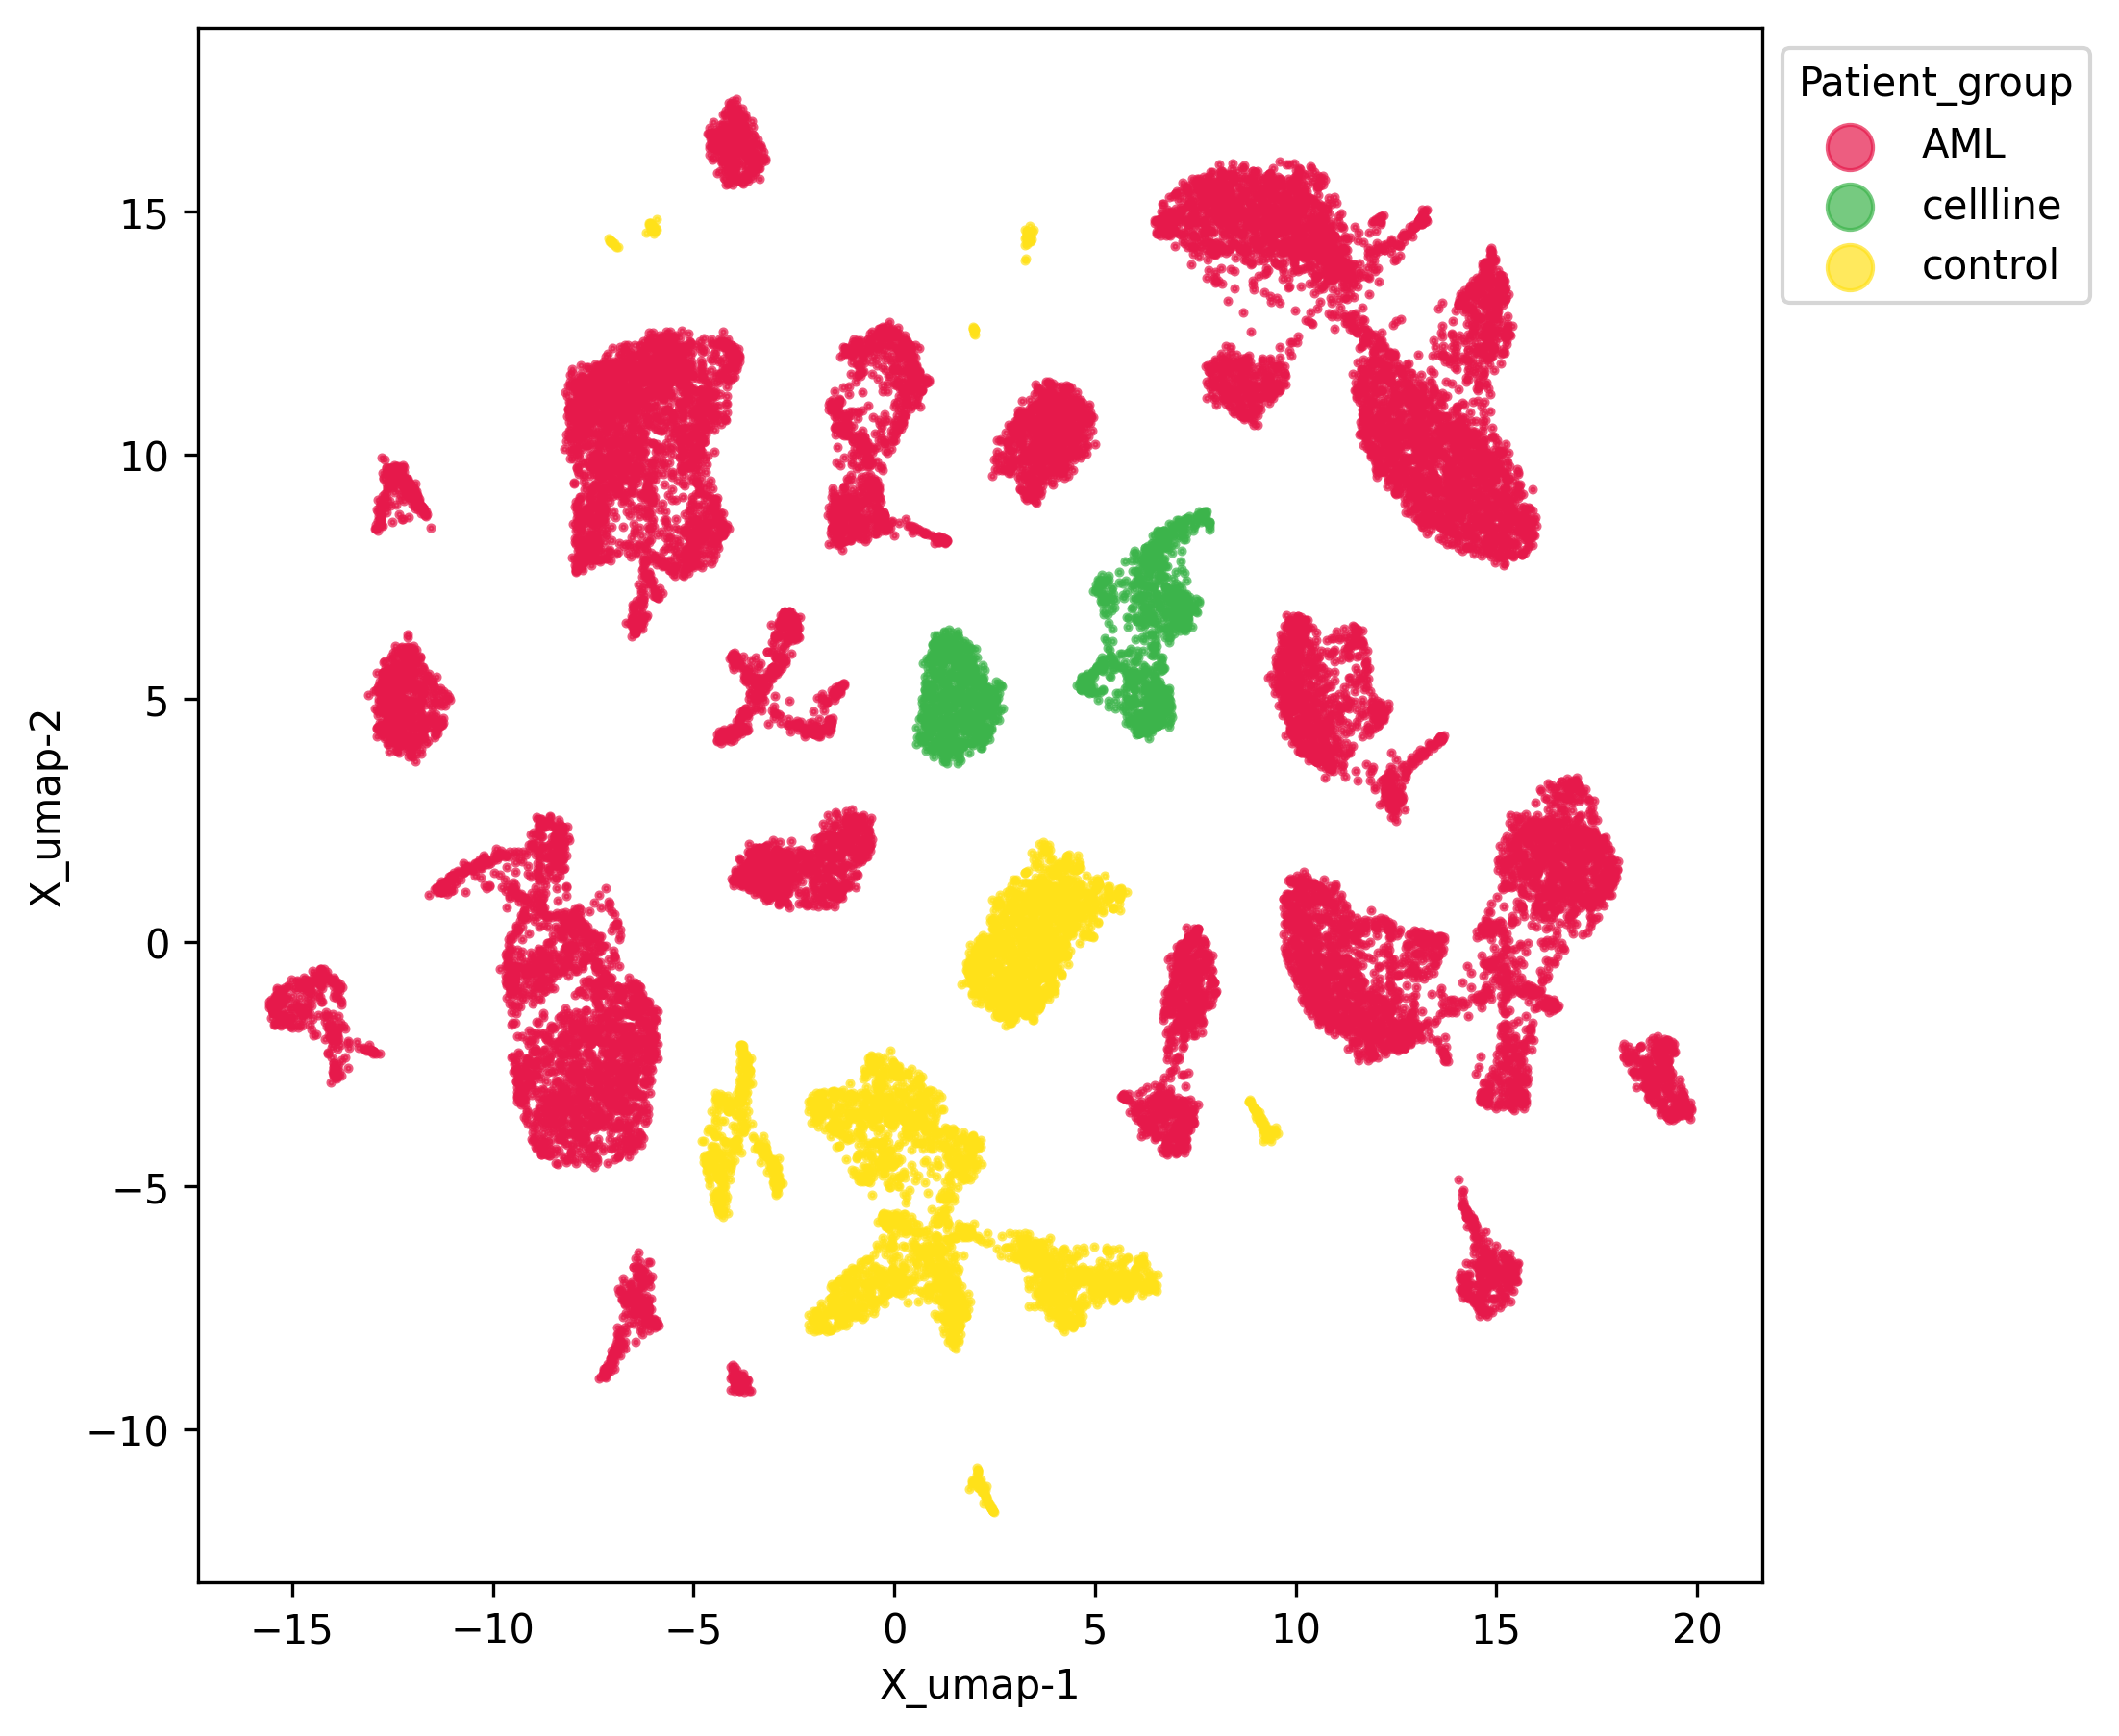
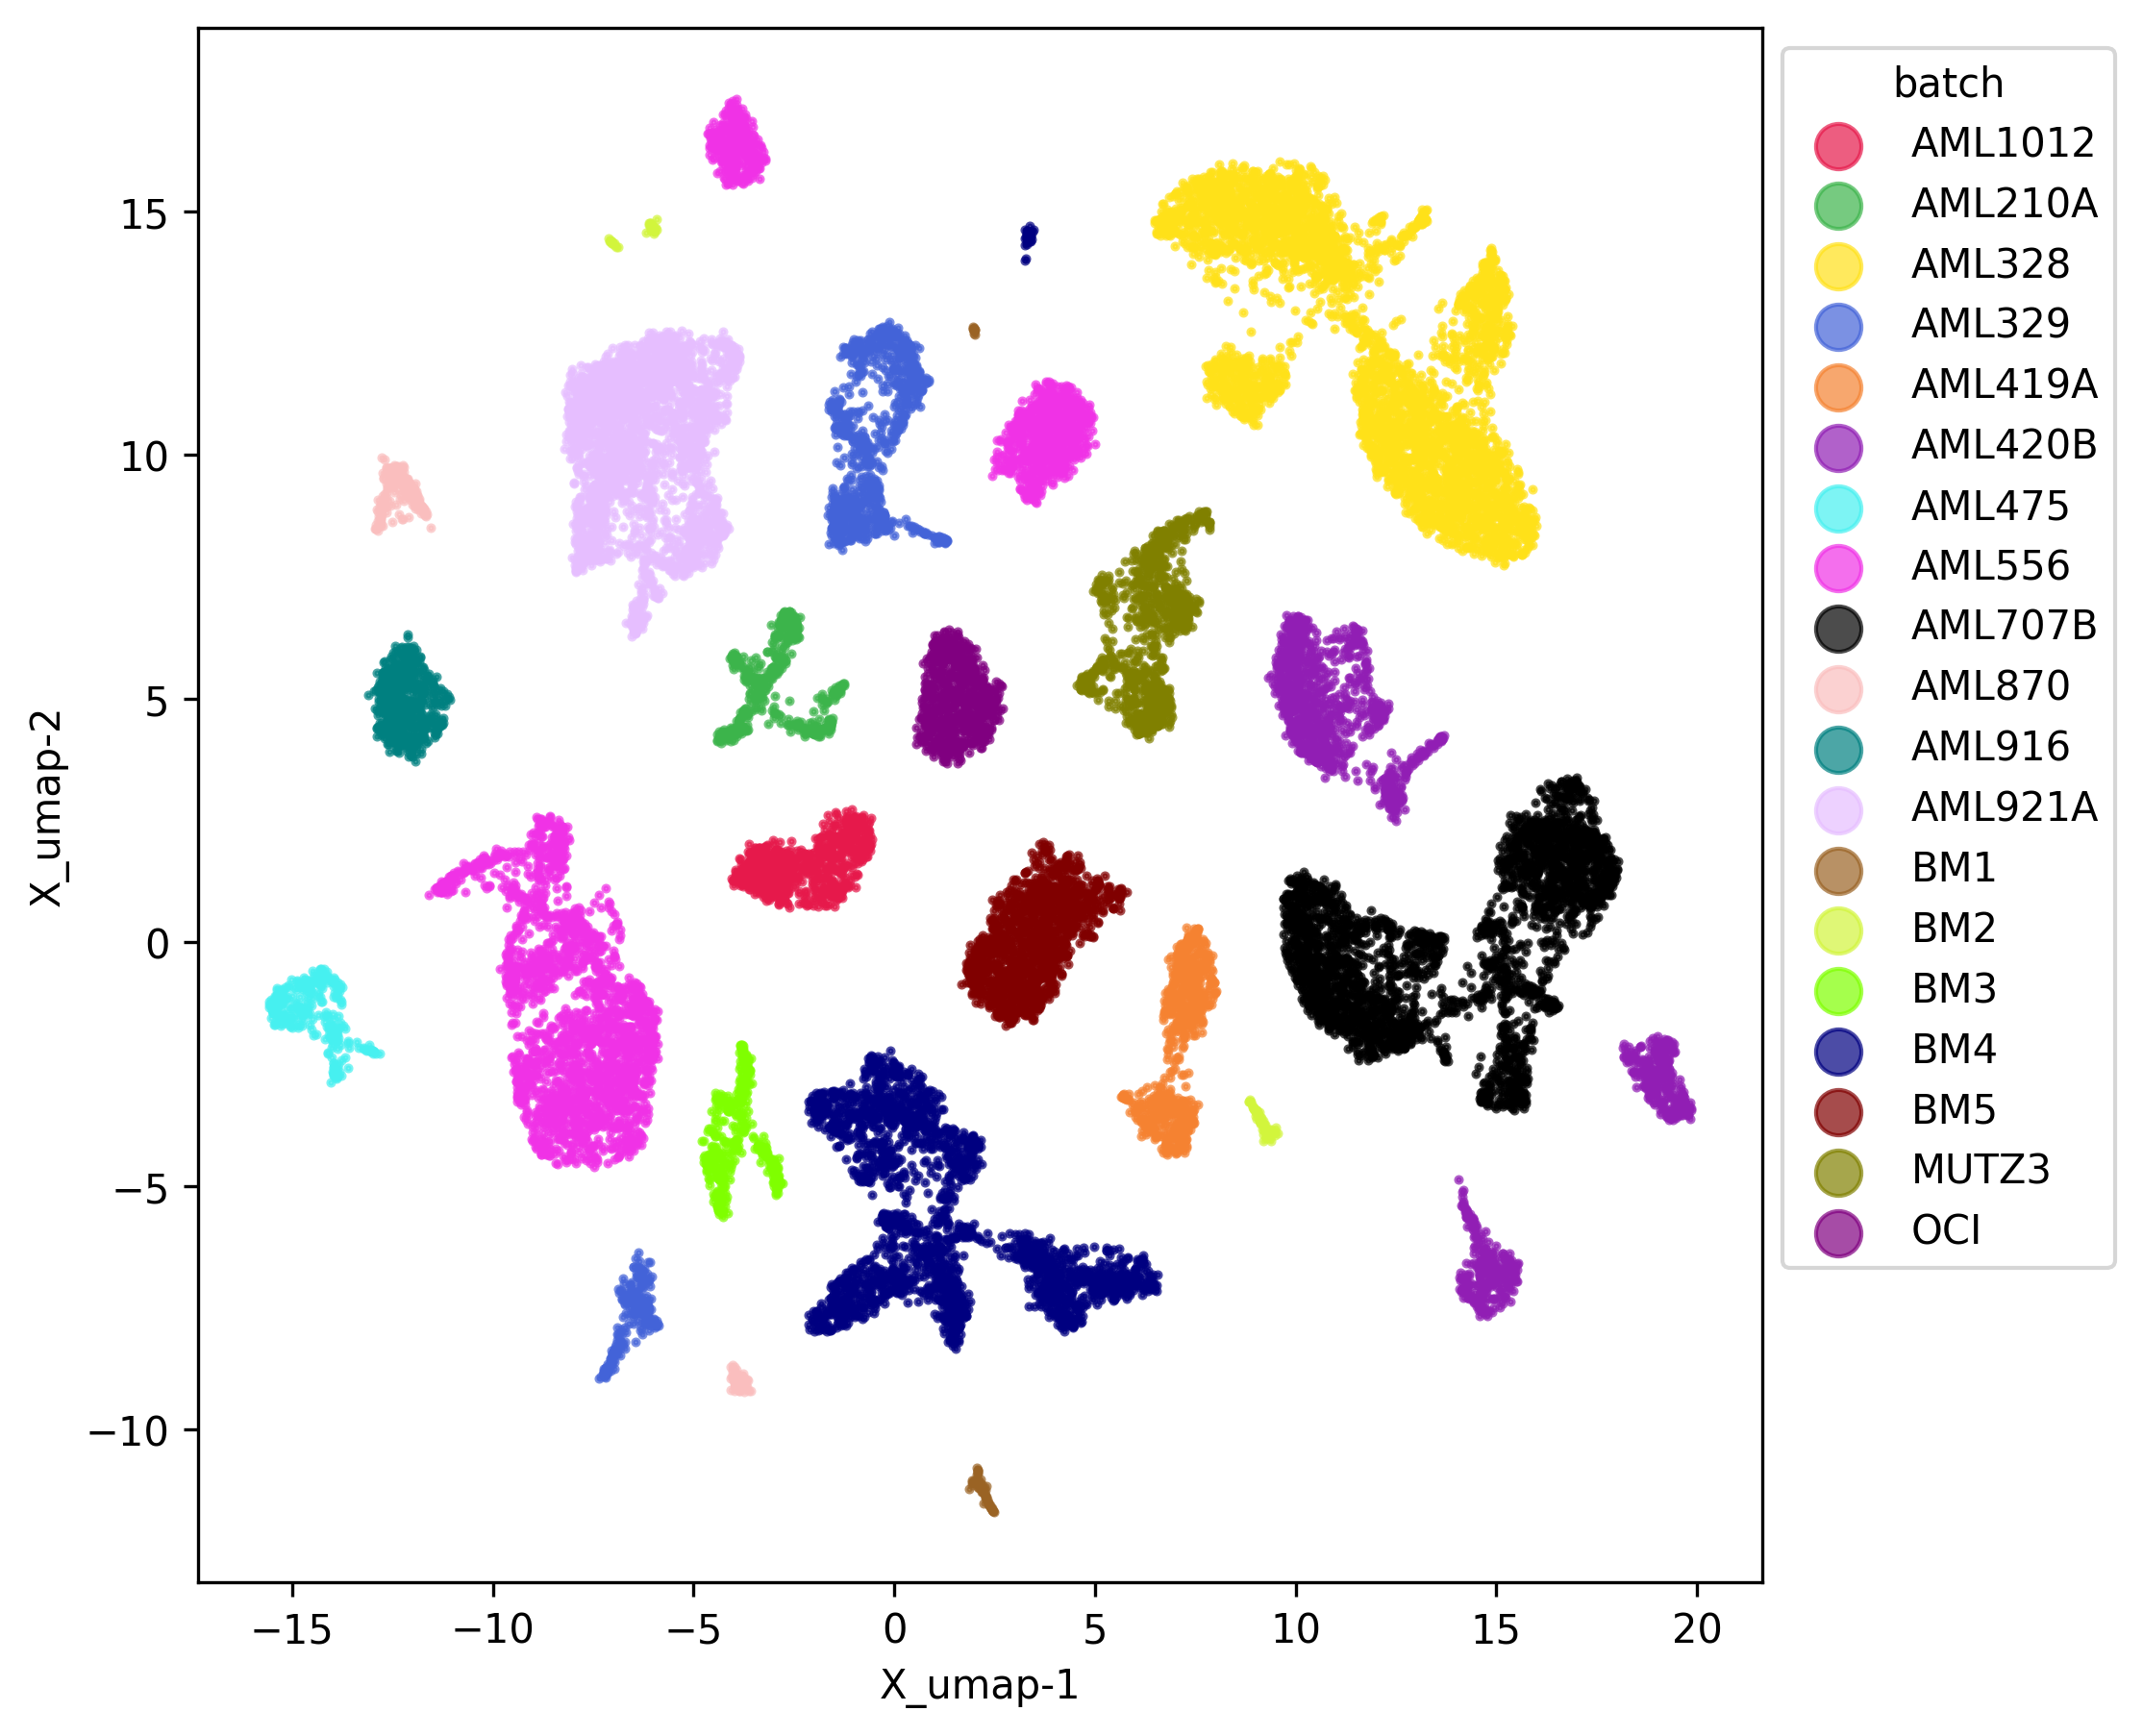
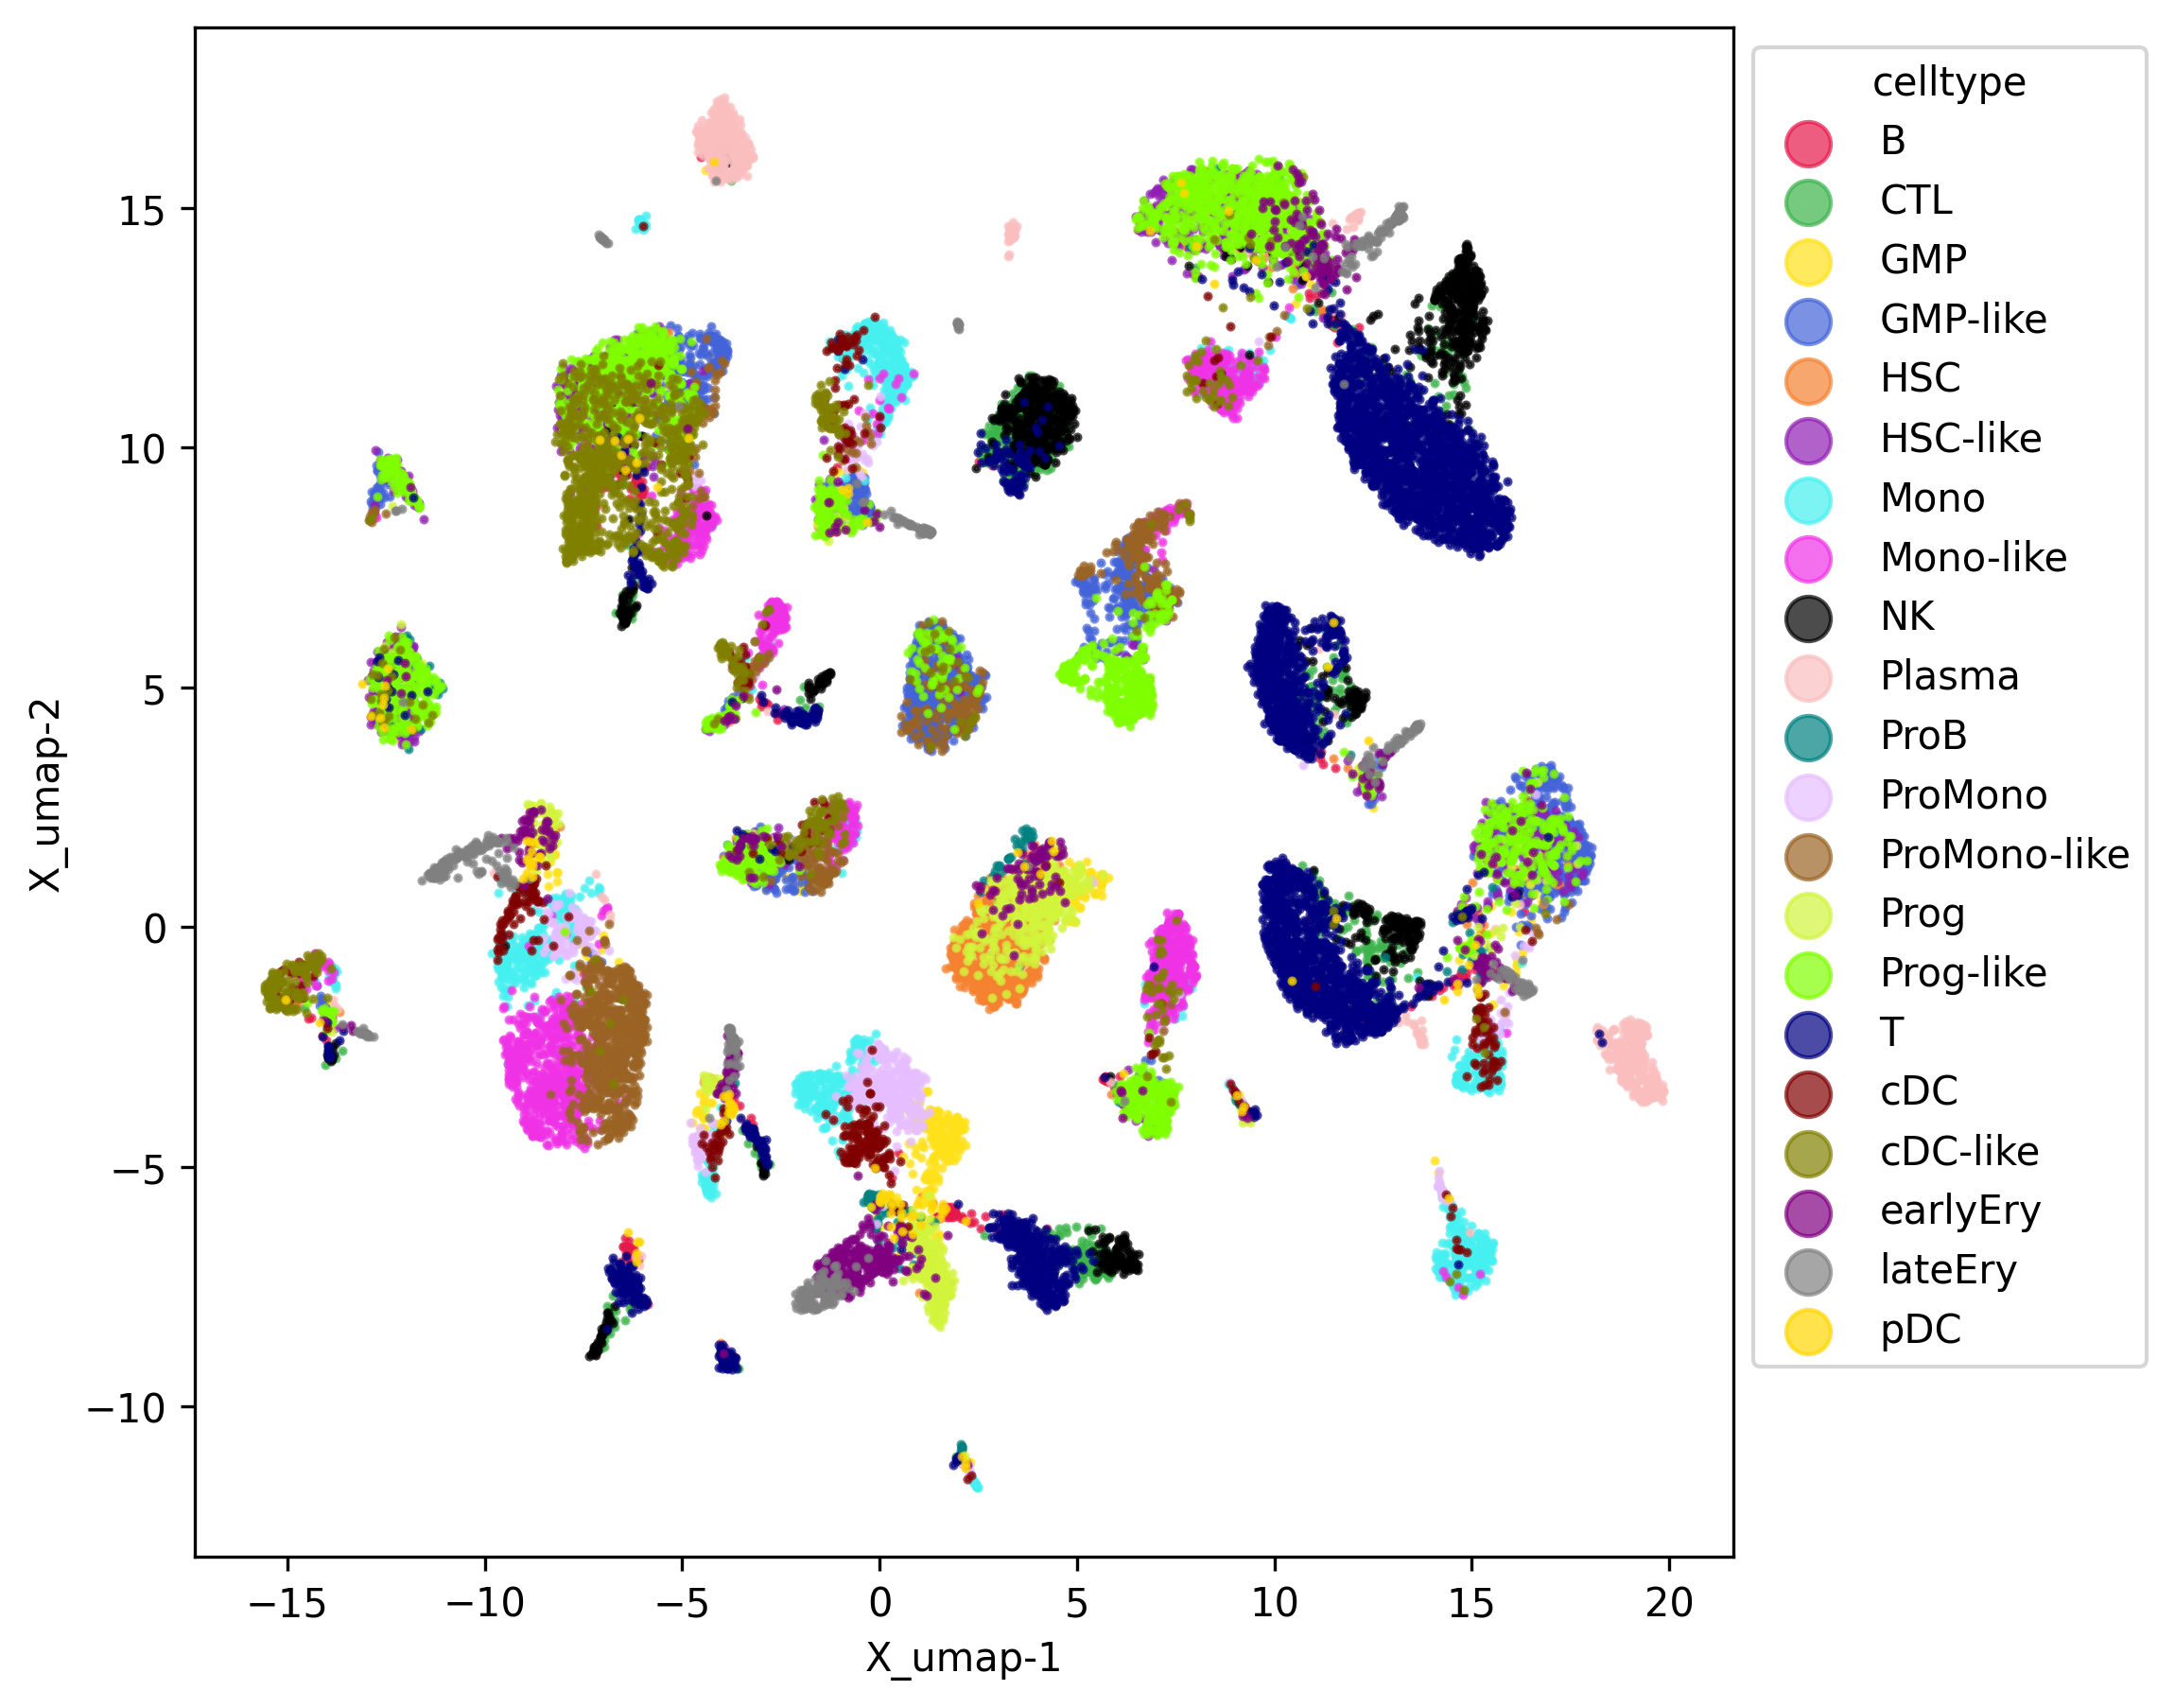

In [4]:
import glob, base64, mimetypes, pathlib
from IPython.display import HTML, display

# ------------------------------------------------------------------
# 1) Collect the figure paths
# ------------------------------------------------------------------
outputs_path = os.path.join(aml.paths.outputs_path, analysis_name)
figs_list = sorted(
    glob.glob(outputs_path + "/*umap*/*plots_axis/*umap*scmedalre*")
)

if not figs_list:
    print("No figures found!")
else:
    # ----------------------------------------------------------------
    # 2) Build one large HTML snippet whose <img> tags use data-URIs
    # ----------------------------------------------------------------
    def to_data_uri(fp: str, max_width: int = 370) -> str:
        mime, _ = mimetypes.guess_type(fp)
        mime = mime or "image/png"                         # fallback
        data = pathlib.Path(fp).read_bytes()
        b64  = base64.b64encode(data).decode()
        return f"<img src='data:{mime};base64,{b64}' "\
               f"style='max-width:{max_width}px;'>"

    html_imgs = "".join(to_data_uri(p) for p in figs_list)
    html_block = (
        "<div style='display:flex; flex-wrap:wrap; gap:10px;'>"
        + html_imgs +
        "</div>"
    )

    display(HTML(html_block))

##### Step 4: Run genomaps on a subsample of the input data along with reconstructions from the scmedalfe and scmedalre models. 

Visualize selected batches to assess batch-specific effects in the reconstructed spaces, including conterfactual projections from scmedalre.

In [4]:
# 

batches = ["AML420B", "BM5", "MUTZ3"]
celltype = ["Mono", "Mono-like"]
# for this genomap config, you need to compute first the reconstructions from scMEDAL-FE and scMEDAL-RE
selected_models = {k: model_folder_dict[k] for k in ("scmedalfe", "scmedalre")}
gfd = aml.genomap(selected_models,
                            n_batches = 19,
                            num_iter = 200, # for quick test, otherwise 100
                            cell_id_col = "Cell",
                            gene_index_col = "Gene",
                            celltype = ["Mono", "Mono-like"],
                            batches=batches,
                            models=['scmedalre'],#if add_inputs_fe=True-> scmedalfe+ inputs are used for genomap creation by default, no need to add the to the list, 
                            types=["train"], 
                            splits=[1],
                            add_inputs_fe= True,
                            extra_recon = "fe",
                            min_val = -1,
                            max_val =2)


Looking for outputs paths for the following models:dict_keys(['scmedalfe', 'scmedalre'])
Created df with input and recon paths


Initialized genomap pipeline ..
genomaps saved to /archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/dev2/scMEDAL_for_scRNAseq/outputs/AML/compare_models/log_transformed_2916hvggenes/AML_default_500_v1.3/genomap 
Run genomap pipeline for:  ['train'] [1] ['scmedalre']
train 1 scmedalre
Reading data from: /archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/dev2/scMEDAL_for_scRNAseq/data/AML_data/log_transformed_2916hvggenes/splits/split_1/train
Batches selected for plotting: ['AML420B', 'BM5', 'MUTZ3']


Sampling adata  multibatch from original data and recons..
Saving to adata multibatch directory: /archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/dev2/scMEDAL_for_scRNAseq/outputs/AML/compare_models/log_transformed_2916hvggenes/AML_default_500_v1.3/genomap/CMmultibatch_300_cells_per_batch_19batches_Mono_Mono-like_with_2fe_input

Sampling cells.. 


/archive/bioinformatics/DLLab/shared/CondaEnvironments/scMEDAL/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


AML420B-D35_CTCGGTCAACGT comes from batch AML420B
AML420B-D35_GCCACCCTAGTG comes from batch AML420B
BM5-34p38n_TGTGGACAAGCA comes from batch BM5
MUTZ3_TAAATCTGATTT comes from batch MUTZ3
Original batch list: ['AML420B', 'AML420B', 'BM5', 'MUTZ3']

Computing genomap..
Reading data from: /archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/dev2/scMEDAL_for_scRNAseq/outputs/AML/compare_models/log_transformed_2916hvggenes/AML_default_500_v1.3/genomap/CMmultibatch_300_cells_per_batch_19batches_Mono_Mono-like_with_2fe_input


/archive/bioinformatics/DLLab/shared/CondaEnvironments/scMEDAL/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/archive/bioinformatics/DLLab/shared/CondaEnvironments/scMEDAL/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


Input does not contain NaNs
subset_input_z_scores shape: (6300, 2916)


...

created plot with no gene labels
plotting small panel for BM5-34p38n_TGTGGACAAGCA with original batch BM5 and celltype Mono, n recons: 5
Saved gene std across batches  to: /archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/dev2/scMEDAL_for_scRNAseq/outputs/AML/compare_models/log_transformed_2916hvggenes/AML_default_500_v1.3/genomap/genomap_plots/Mono/singlecell_gene_std_acrossbatches/genomap_BM5-34p38n_TGTGGACAAGCA_std_10topvariablegenesacrossbatches.csv


plotting big panel for single cell BM5-34p38n_TGTGGACAAGCA from original batch BM5 and celltype Mono, n recons: 21


/endosome/archive/bioinformatics/DLLab/src/AixaAndrade/gitfront/dev2/scMEDAL_for_scRNAseq/utils/genomaps_utils.py:1034: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 0.9, 0.97])


created plot with no gene labels
plotting small panel for MUTZ3_TAAATCTGATTT with original batch MUTZ3 and celltype Mono-like, n recons: 5
Saved gene std across batches  to: /archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/dev2/scMEDAL_for_scRNAseq/outputs/AML/compare_models/log_transformed_2916hvggenes/AML_default_500_v1.3/genomap/genomap_plots/Mono-like/singlecell_gene_std_acrossbatches/genomap_MUTZ3_TAAATCTGATTT_std_10topvariablegenesacrossbatches.csv


plotting big panel for single cell MUTZ3_TAAATCTGATTT from original batch MUTZ3 and celltype Mono-like, n recons: 21


/endosome/archive/bioinformatics/DLLab/src/AixaAndrade/gitfront/dev2/scMEDAL_for_scRNAseq/utils/genomaps_utils.py:1034: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 0.9, 0.97])


created plot with no gene labels


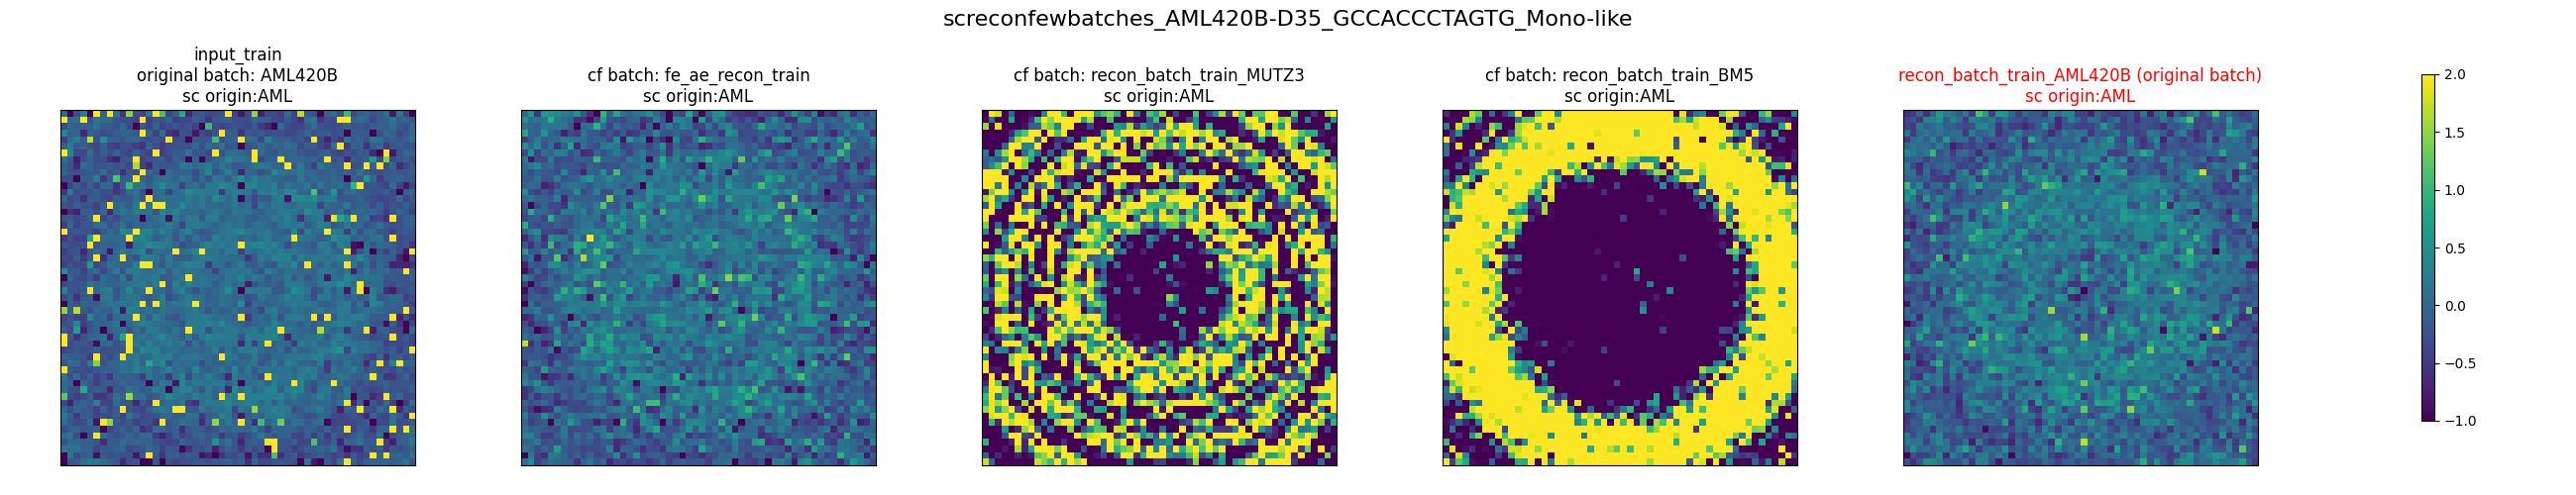

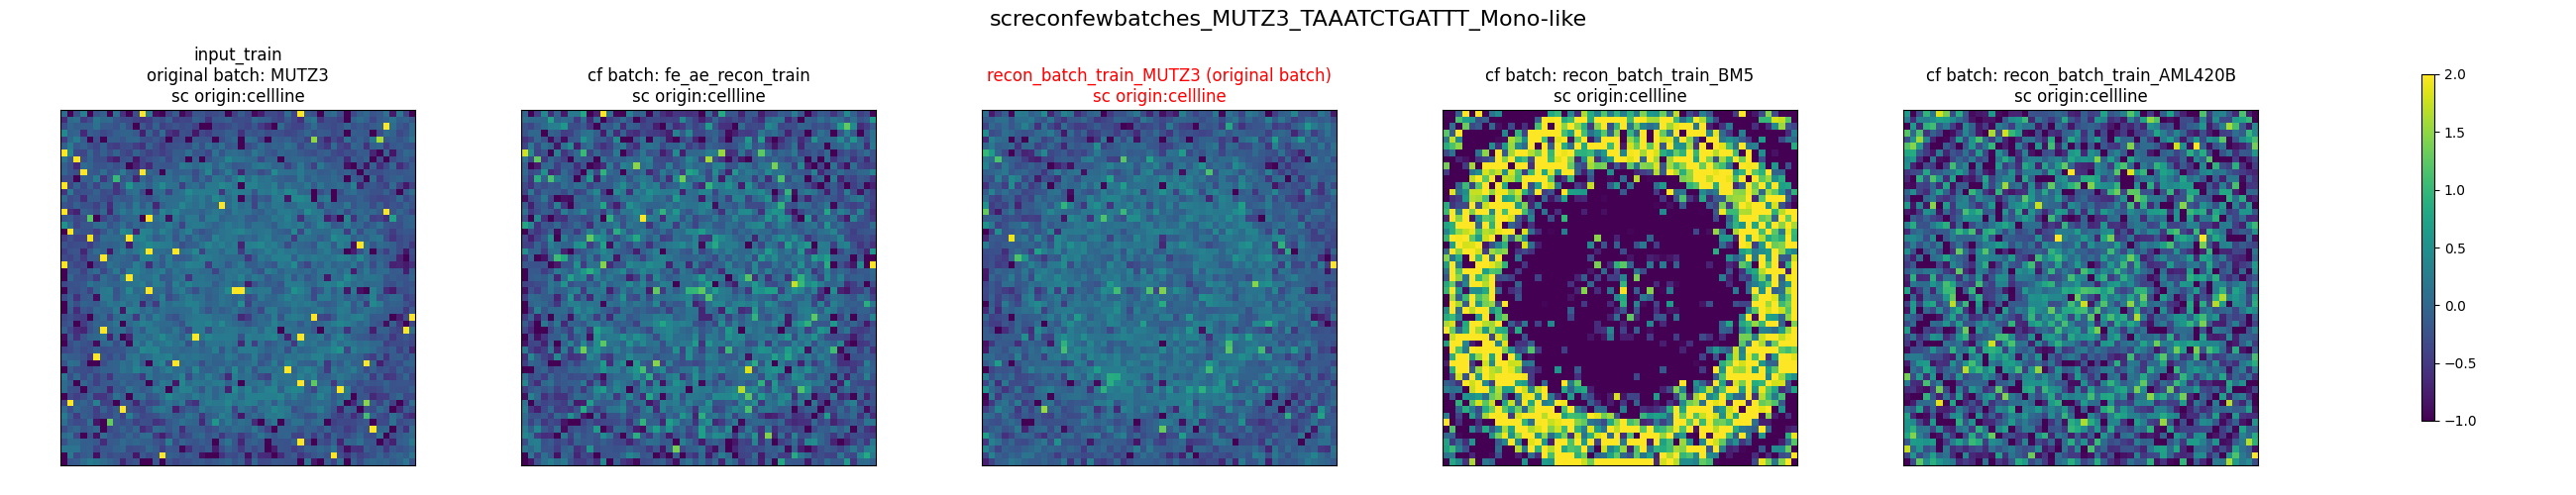

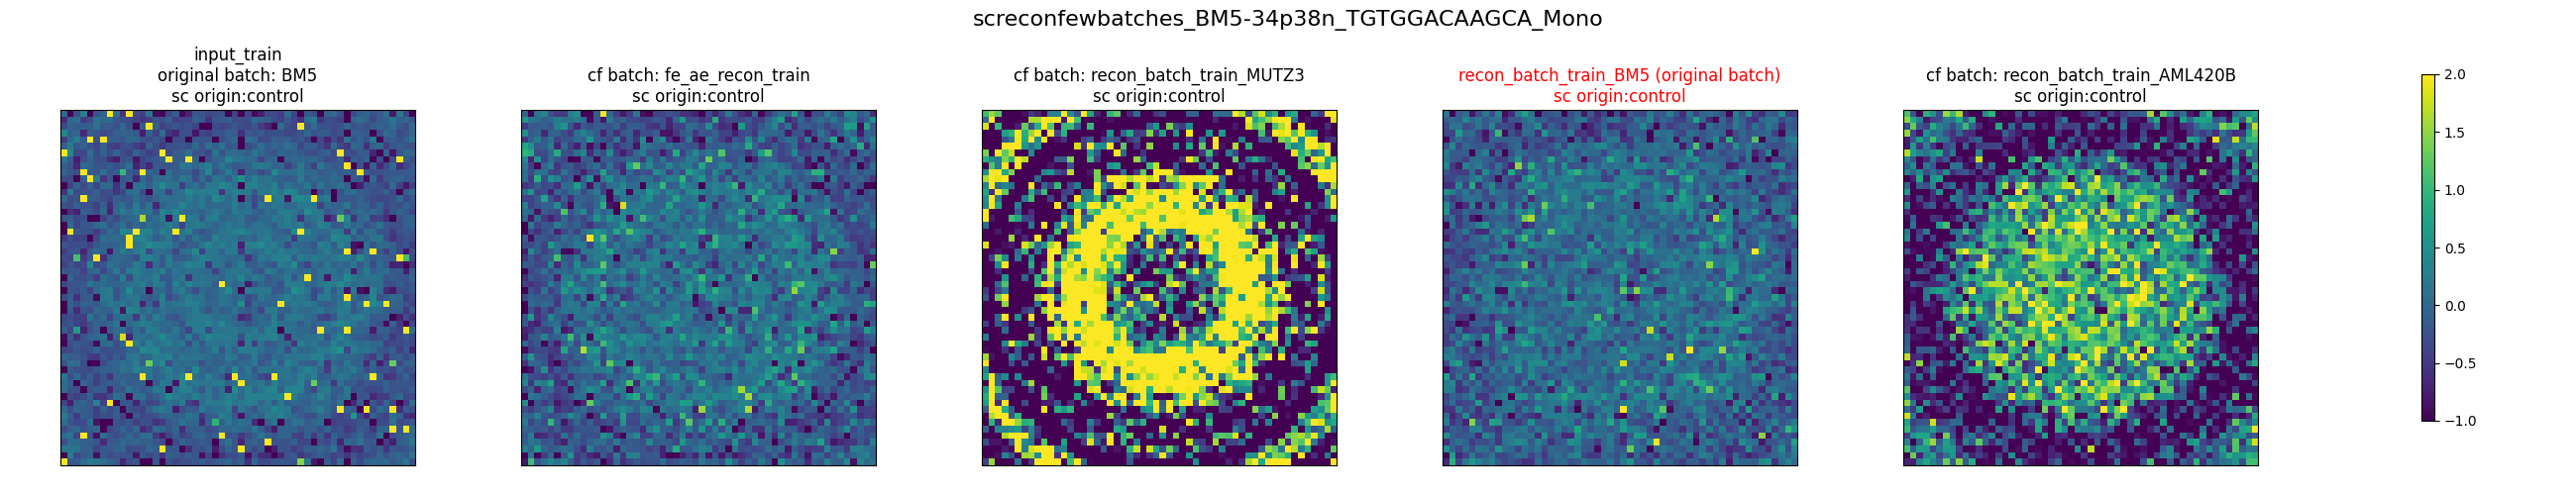

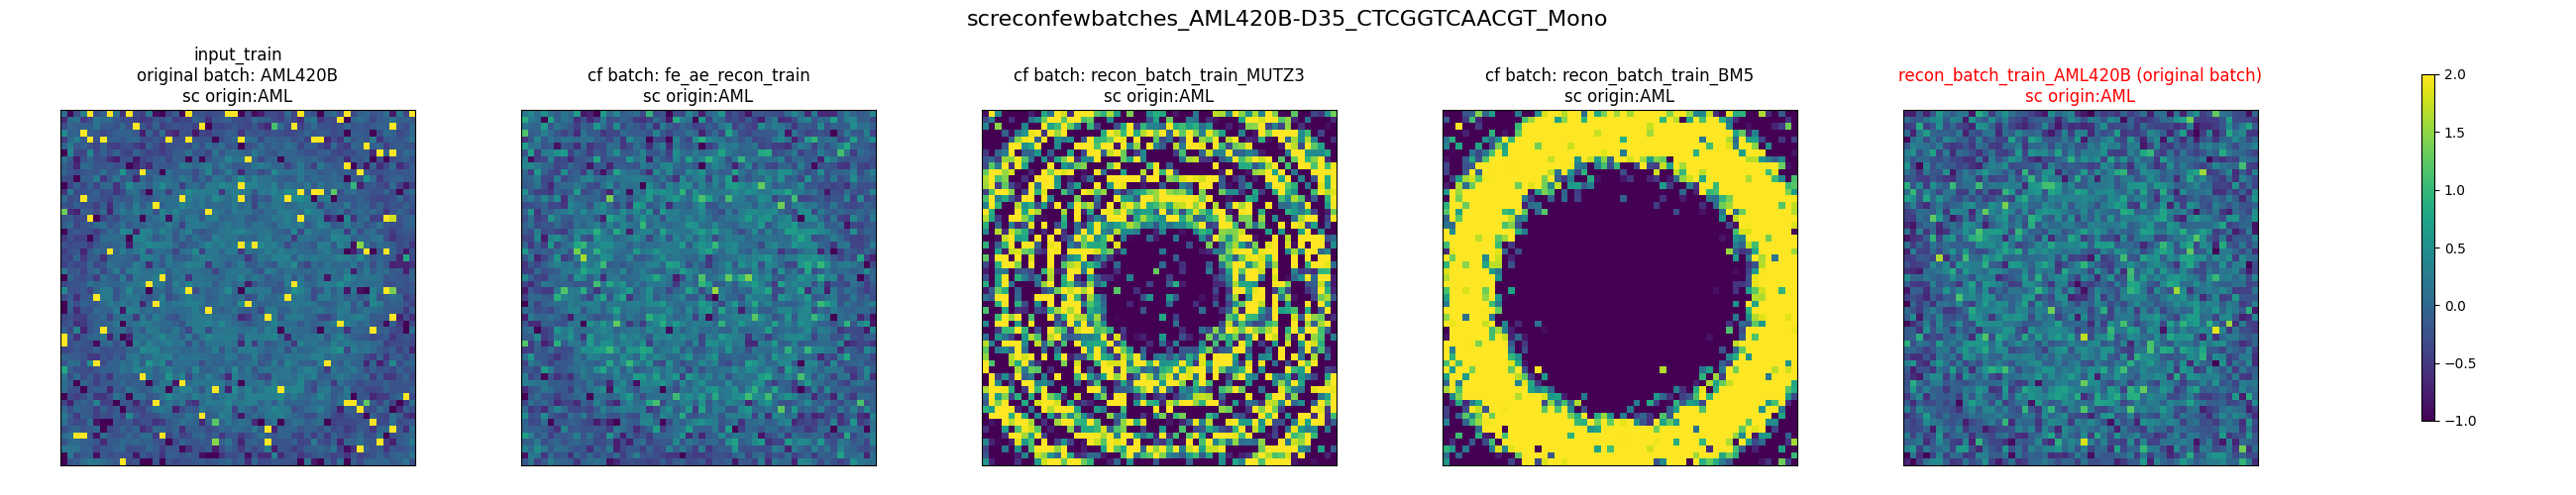

In [5]:
# View genomap images
import glob
from IPython.display import Image, display


genomap_path = os.path.join(
    aml.paths.outputs_path, 
    analysis_name, 
    "genomap", 
    "genomap_plots"
)
# Make sure this path leads to the stored genomap figures
figs_list = glob.glob(
    os.path.join(genomap_path, "*", "*genomap_plots_scfewbatches_nogenelabels", "*")
)

# Show all figures
for fig in figs_list:
    display(Image(filename=fig))

## Run the Mixed Effects Classifier (MEC) on latent spaces generated by scmedalfe and scmedalre.

Classification target: 3 patient groups (e.g., AML vs Normal vs cell line)

$python\ mec\_aml.py$

In [4]:
# Now get a summary table of all mec results
from utils.compare_results_utils import get_all_mec_metrics
df,_ = get_all_mec_metrics(AML_OUTPUTS_DIR,AML_EXPERIMENT_NAME, split='test')
df

MEC RF summary able saved to /archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/dev2/scMEDAL_for_scRNAseq/outputs/AML/latent_space/log_transformed_2916hvggenes/mec/MEC_RF_summary.csv


,latent,RFAccuracy_mean,RFAccuracy_95CI_lower,RFAccuracy_95CI_upper,RFBalancedAccuracy_mean,RFBalancedAccuracy_95CI_lower,RFBalancedAccuracy_95CI_upper,ChanceAccuracy_mean,ChanceAccuracy_95CI_lower,ChanceAccuracy_95CI_upper,run_name
0,harmony_latent,76.50,76.10,76.90,38.27,36.74,39.80,60.82,60.37,61.27,harmony_latent_n_pred-3_bio_col-Patient_group_...
0,scanorama_latent,85.60,84.44,86.76,67.36,63.25,71.46,60.82,60.37,61.27,scanorama_latent_n_pred-3_bio_col-Patient_grou...
0,scVI_latent,88.43,87.61,89.24,76.13,72.90,79.37,60.82,60.37,61.27,scVI_latent_n_pred-3_bio_col-Patient_group_202...
0,scANVI_latent,89.87,89.53,90.21,78.09,76.58,79.61,60.82,60.37,61.27,scANVI_latent_n_pred-3_bio_col-Patient_group_2...
0,scmedalfec_latent,91.97,91.15,92.79,83.85,82.07,85.64,60.82,60.37,61.27,scmedalfec_latent_n_pred-3_bio_col-Patient_gro...
0,scmedalfe_latent,92.85,92.17,93.53,86.03,83.92,88.15,60.82,60.37,61.27,scmedalfe_latent_n_pred-3_bio_col-Patient_grou...
0,SAUCIE_latent,91.80,90.67,92.93,86.21,83.75,88.66,60.82,60.37,61.27,SAUCIE_latent_n_pred-3_bio_col-Patient_group_2...
0,X_pca,93.88,93.00,94.75,88.74,86.62,90.87,60.82,60.37,61.27,X_pca_n_pred-3_bio_col-Patient_group_2025-07-1...
0,scVI_latent_re_latent-scmedalre_latent,99.94,99.88,99.99,99.88,99.78,99.98,60.82,60.37,61.27,scVI_latent_re_latent-scmedalre_latent_n_pred-...
0,SAUCIE_latent_re_latent-scmedalre_latent,99.94,99.88,100.00,99.89,99.79,100.00,60.82,60.37,61.27,SAUCIE_latent_re_latent-scmedalre_latent_n_pre...
